# 01. EDA and Baseline — Human Pancreatic Islet Integration Benchmark

Same dataset the official scvi-tools tutorials use (Reference mapping, Seed labeling
with scANVI). Nine "technologies" in the metadata, which is really four independent
studies with some technical replicates thrown in: Baron et al. (inDrop1-4), Muraro et
al. (celseq/celseq2), Segerstolpe et al. (smartseq2), Xin et al. (smarter,
fluidigmc1). 16,382 cells, 19,093 genes, 14 annotated cell types.

**On the data source**: the Figshare link from older tutorial versions is currently
behind anti-bot protection and returns a 403 instead of the file — not the ideal way to
start a notebook. scvi-tools apparently hit the same wall and moved everything to their
own server:

```
https://exampledata.scverse.org/scvi-tools/pancreas.h5ad
```

That's the link used below.

**On QC, since this matters for interpreting anything downstream**: this is not raw
sequencer output. The scIB benchmark authors already filtered it before release — there
are no mitochondrial genes in the object at all, and the `counts` layer is reconstructed
from scran size factors rather than being integer UMI counts. Fine for a benchmark, but
worth saying out loud rather than presenting this as an "from-scratch" QC pass.

Source: Luecken M.D. et al., "Benchmarking atlas-level data integration in single-cell
genomics", Nature Methods 2022 (the scIB manuscript).


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
print(f"scanpy: {sc.__version__}")

scanpy: 1.12.2


## 1. Loading the data

In [2]:
adata = sc.read(
    "../data/raw/pancreas.h5ad",
    backup_url="https://exampledata.scverse.org/scvi-tools/pancreas.h5ad",
)
print(adata)
print("\nBatches (technology / sub-sample):")
print(adata.obs["tech"].value_counts())
print("\nCell types:")
print(adata.obs["celltype"].value_counts())

AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors'
    layers: 'counts', None (.X)

Batches (technology / sub-sample):
tech
inDrop3       3605
smartseq2     2394
celseq2       2285
inDrop1       1937
inDrop2       1724
smarter       1492
inDrop4       1303
celseq        1004
fluidigmc1     638
Name: count, dtype: int64

Cell types:
celltype
alpha                 5493
beta                  4169
ductal                2142
acinar                1669
delta                 1055
gamma                  699
activated_stellate     464
endothelial            313
quiescent_stellate     193
macrophage              79
mast                    42
epsilon                 32
schwann                 25
t_cell                   7
Name: count, dtype: int64


## 2. EDA: batch and cell-type structure

The 9 `tech` values actually correspond to 4 independent studies, some of which ran
several technical replicates (e.g. Baron et al. — inDrop1..inDrop4). Note the rare cell
types (`t_cell`: 7 cells, `schwann`: 25, `epsilon`: 32) — any integration method will be
unreliable for them simply due to sample size, which is worth keeping in mind when
interpreting metrics later.

In [3]:
cross_tab = pd.crosstab(adata.obs["celltype"], adata.obs["tech"])
cross_tab

tech,celseq,celseq2,fluidigmc1,inDrop1,inDrop2,inDrop3,inDrop4,smarter,smartseq2
celltype,,,,,,,,,
acinar,228,274,21,110,3,843,2,0,188
activated_stellate,19,90,16,51,81,100,52,0,55
alpha,191,843,239,236,676,1130,284,886,1008
beta,161,445,258,872,371,787,495,472,308
delta,50,203,25,214,125,161,101,49,127
ductal,327,258,36,120,301,376,280,0,444
endothelial,5,21,14,130,23,92,7,0,21
epsilon,1,4,1,13,2,2,1,0,8
gamma,18,110,18,70,86,36,63,85,213


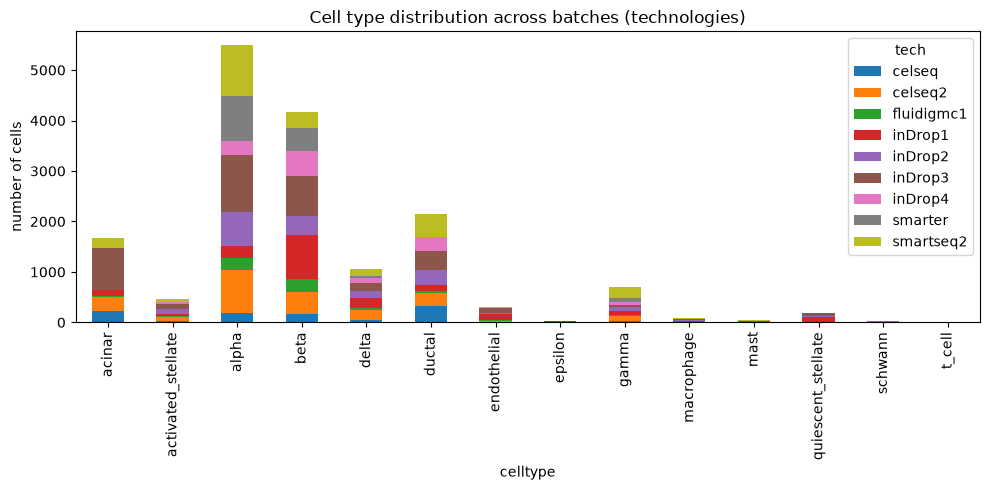

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
cross_tab.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("number of cells")
ax.set_title("Cell type distribution across batches (technologies)")
plt.tight_layout()
plt.savefig("../results/figures/01_celltype_by_batch.png", dpi=150)
plt.show()

## 3. Highly variable gene selection and baseline PCA/UMAP

The full set of 19,093 genes is redundant and noisy for PCA — standard practice is to
select ~2000 informative genes, and to do so **batch-aware** (`batch_key="tech"`), so we
don't end up selecting genes whose variability is just a technical artifact of one lab.

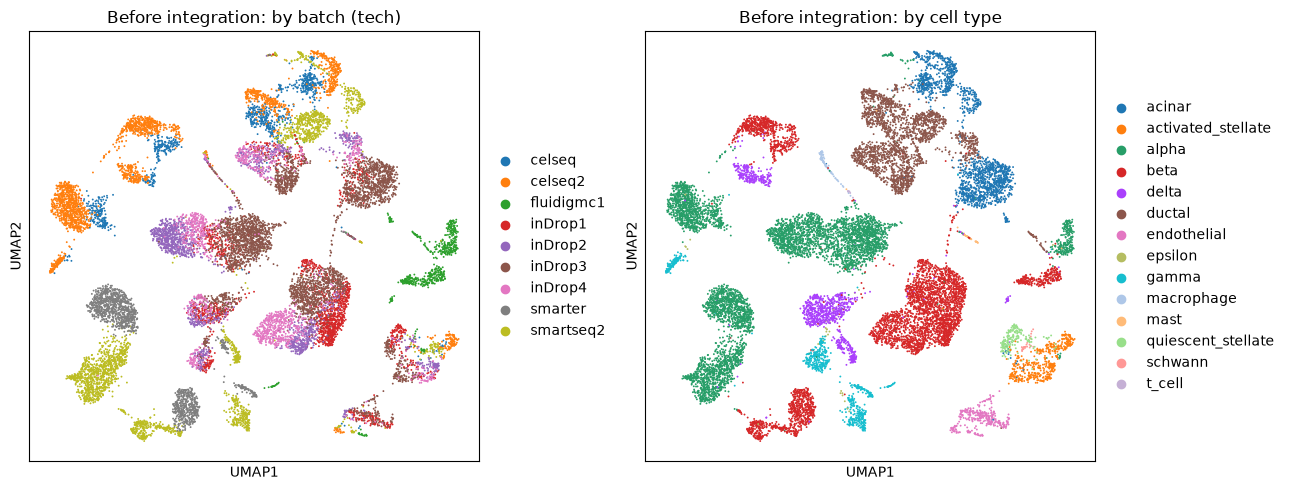

In [5]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="tech", subset=False)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=30)
sc.pp.neighbors(adata_hvg)
sc.tl.umap(adata_hvg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata_hvg, color="tech", ax=axes[0], show=False, title="Before integration: by batch (tech)")
sc.pl.umap(adata_hvg, color="celltype", ax=axes[1], show=False, title="Before integration: by cell type")
plt.tight_layout()
plt.savefig("../results/figures/01_baseline_umap.png", dpi=150)
plt.show()

**Two things worth writing down after looking at the plot, not just eyeballing it:**
- how strongly cells group by `tech` rather than `celltype` on this baseline UMAP — this
  is the number we'll compare Harmony/scVI/scANVI against later
- whether the more abundant cell types (alpha, beta) already mix reasonably well even
  without correction, while the rare ones don't — that pattern shows up again later

## 4. Saving the prepared data

Saving the full gene set here, not just the HVG subset — each integration method gets to
redo its own HVG selection if it wants a different set.

In [6]:
adata.write("../data/processed/pancreas_prepared.h5ad")
print("Saved:", adata.shape)

Saved: (16382, 19093)


## Conclusions

The batch effect is obvious on the UMAP, not subtle: plate-based technologies
(celseq, celseq2, smarter, smartseq2) form islands that sit outside the main cloud of
droplet-based data, even though the same cell types are present in both. Rare types
(t_cell: 7 cells total, schwann: 25, epsilon: 32) show up in only a few of the nine
batches, so any integration method is going to be shaky for them purely on sample-size
grounds — worth keeping in mind before reading too much into their behavior later.

Next up: Harmony, in `02_baseline_integration.ipynb`, to see whether those islands
actually collapse or not.
